# Water Quality Prediction Model Training

This notebook trains a Random Forest model to predict water potability based on:
- pH level
- Total Dissolved Solids (TDS/Solids)
- Turbidity (NTU)

**Dataset Source:** Kaggle Water Potability Dataset

**Model Output:** Binary classification (0 = Not Potable, 1 = Potable)

## 1. Import Libraries

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load Dataset

**Dataset Columns:**
- `ph`: pH value of water
- `Hardness`: Water hardness (not used in our model)
- `Solids`: Total Dissolved Solids (TDS)
- `Chloramines`: Chloramine levels (not used)
- `Sulfate`: Sulfate levels (not used)
- `Conductivity`: Electrical conductivity (not used)
- `Organic_carbon`: Organic carbon levels (not used)
- `Trihalomethanes`: THM levels (not used)
- `Turbidity`: Turbidity in NTU
- `Potability`: Target variable (0 = Not Potable, 1 = Potable)

In [76]:
# Load dataset
df = pd.read_csv('water_potability.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (3000, 7)

Columns: ['_key', 'Turbidity', 'ph', 'Potability', 'Solids', 'timestamp', 'rule']

First 5 rows:


,_key,Turbidity,ph,Potability,Solids,timestamp,rule
0,100000,2.23,8.03,0,570.9,04:03:03,R12
1,100001,3.78,7.00,1,215.8,17:50:11,R21
2,100002,0.10,7.93,0,577.7,02:54:17,R14
3,100003,0.81,6.61,1,281.0,20:38:24,R17
4,100004,0.26,7.29,1,102.9,21:54:03,R18


## 3. Data Exploration

In [77]:
# Basic statistics
print("Dataset Info:")
print("=" * 50)
df.info()

print("\nBasic Statistics:")
print("=" * 50)
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   _key        3000 non-null   int64  
 1   Turbidity   3000 non-null   float64
 2   ph          3000 non-null   float64
 3   Potability  3000 non-null   int64  
 4   Solids      3000 non-null   float64
 5   timestamp   3000 non-null   object 
 6   rule        3000 non-null   object 
dtypes: float64(3), int64(2), object(2)
memory usage: 164.2+ KB

Basic Statistics:


,_key,Turbidity,ph,Potability,Solids
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,101499.500000,12.378737,7.214680,0.500000,427.328167
std,866.169729,31.336148,0.765828,0.500083,335.260699
min,100000.000000,0.100000,4.000000,0.000000,50.500000
25%,100749.750000,0.640000,6.940000,0.000000,187.100000
50%,101499.500000,2.350000,7.010000,0.500000,349.550000
75%,102249.250000,7.442500,7.570000,1.000000,549.525000
max,102999.000000,198.080000,9.970000,1.000000,1799.600000


In [78]:
# Check missing values
print("Missing Values:")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values:
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []


Target Distribution (Potability):
Potability
0    1500
1    1500
Name: count, dtype: int64

Percentage:
Potability
0    50.0
1    50.0
Name: proportion, dtype: float64


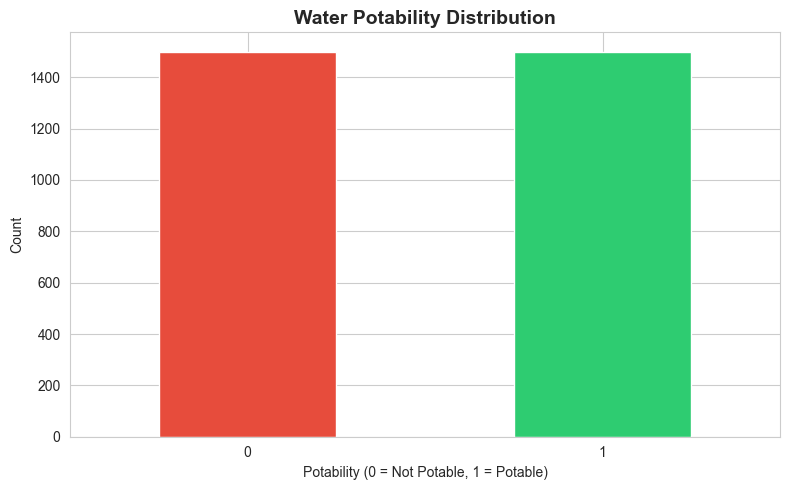

In [79]:
# Check target distribution
print("Target Distribution (Potability):")
print("=" * 50)
print(df['Potability'].value_counts())
print(f"\nPercentage:")
print(df['Potability'].value_counts(normalize=True) * 100)

# Visualize
plt.figure(figsize=(8, 5))
df['Potability'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title('Water Potability Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Potability (0 = Not Potable, 1 = Potable)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Feature Selection

We only use 3 features that correspond to our IoT sensors:
- `ph` → pH sensor
- `Solids` → TDS sensor
- `Turbidity` → NTU sensor

In [80]:
# Select only relevant features
features = ['ph', 'Solids', 'Turbidity']
target = 'Potability'

# Create subset
df_model = df[features + [target]].copy()

print(f"Selected Features: {features}")
print(f"Target: {target}")
print(f"\nDataset shape: {df_model.shape}")
print(f"\nMissing values in selected features:")
print(df_model.isnull().sum())

Selected Features: ['ph', 'Solids', 'Turbidity']
Target: Potability

Dataset shape: (3000, 4)

Missing values in selected features:
ph            0
Solids        0
Turbidity     0
Potability    0
dtype: int64


## 5. Data Preprocessing

In [81]:
# Handle missing values by filling with median
print("Handling missing values...")
print(f"Before: {df_model.isnull().sum().sum()} missing values")

for col in features:
    if df_model[col].isnull().sum() > 0:
        median_value = df_model[col].median()
        df_model[col].fillna(median_value, inplace=True)
        print(f"  - Filled {col} with median: {median_value:.2f}")

print(f"After: {df_model.isnull().sum().sum()} missing values")
print("\n✅ Data preprocessing complete!")

Handling missing values...
Before: 0 missing values
After: 0 missing values

✅ Data preprocessing complete!


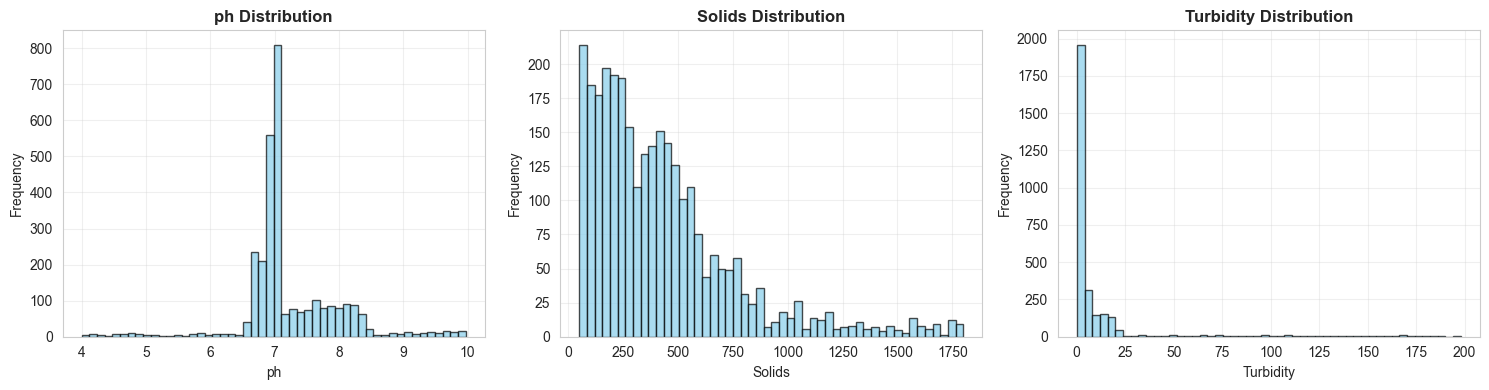

In [82]:
# Visualize feature distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, feature in enumerate(features):
    axes[idx].hist(df_model[feature], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{feature} Distribution', fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

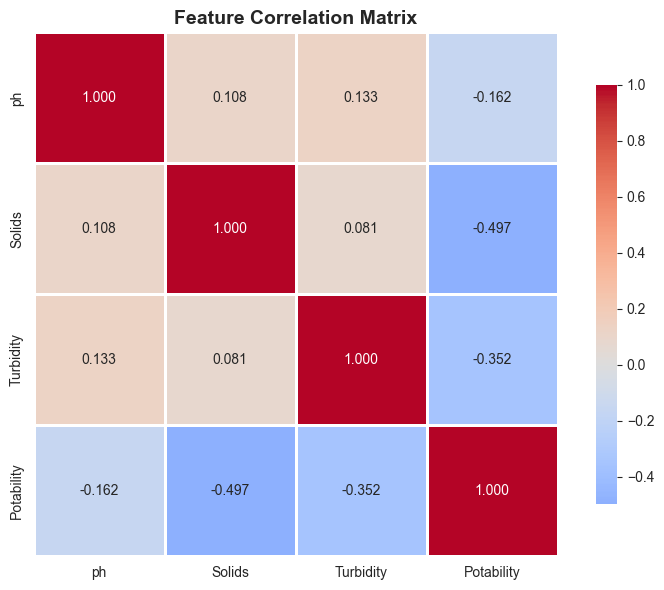

Correlation with Target (Potability):
Potability    1.000000
ph           -0.161673
Turbidity    -0.352252
Solids       -0.496996
Name: Potability, dtype: float64


In [83]:
# Correlation matrix
plt.figure(figsize=(8, 6))
correlation = df_model.corr()
sns.heatmap(correlation, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation with Target (Potability):")
print(correlation['Potability'].sort_values(ascending=False))

In [84]:
# Prepare features and target
# Gunakan hanya features asli (bukan kolom kategori untuk training)
X = df_model[features].copy()
y = df_model[target].copy()

# Validasi tidak ada missing values
print(f"Validasi sebelum split:")
print(f"{'='*50}")
print(f"Missing values di X: {X.isnull().sum().sum()}")
print(f"Missing values di y: {y.isnull().sum()}")

if X.isnull().sum().sum() > 0 or y.isnull().sum() > 0:
    print("\n⚠️ WARNING: Ada missing values! Menghapus rows dengan missing values...")
    valid_idx = ~(X.isnull().any(axis=1) | y.isnull())
    X = X[valid_idx].reset_index(drop=True)
    y = y[valid_idx].reset_index(drop=True)
    df_model = df_model[valid_idx].reset_index(drop=True)
    print(f"Rows setelah pembersihan: {len(X)}")
else:
    print("✅ Tidak ada missing values")

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n{'='*50}")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"\nTraining target distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTesting target distribution:")
print(y_test.value_counts().sort_index())
print(f"\n✅ Data split berhasil!")

Validasi sebelum split:
Missing values di X: 0
Missing values di y: 0
✅ Tidak ada missing values

Training set: 2400 samples
Testing set: 600 samples

Training target distribution:
Potability
0    1200
1    1200
Name: count, dtype: int64

Testing target distribution:
Potability
0    300
1    300
Name: count, dtype: int64

✅ Data split berhasil!


## 7. Train Random Forest Model

In [85]:
# Initialize and train model
print("Training Random Forest Classifier...")
print("=" * 50)

model = RandomForestClassifier(
    n_estimators=100,        # Number of trees
    max_depth=10,            # Maximum depth of trees
    min_samples_split=10,    # Minimum samples to split a node
    min_samples_leaf=5,      # Minimum samples in leaf node
    random_state=42,         # For reproducibility
    n_jobs=-1                # Use all CPU cores
)

# Train the model
model.fit(X_train, y_train)

print("✅ Model training complete!")
print(f"\nModel Parameters:")
print(f"  - Number of trees: {model.n_estimators}")
print(f"  - Max depth: {model.max_depth}")
print(f"  - Features used: {model.n_features_in_}")

Training Random Forest Classifier...
✅ Model training complete!

Model Parameters:
  - Number of trees: 100
  - Max depth: 10
  - Features used: 3


## 8. Model Evaluation

In [86]:
# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test)
test_recall = recall_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)

print("Model Performance:")
print("=" * 50)
print(f"Training Accuracy:   {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Testing Accuracy:    {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Precision:           {test_precision:.4f}")
print(f"Recall:              {test_recall:.4f}")
print(f"F1-Score:            {test_f1:.4f}")

Model Performance:
Training Accuracy:   0.9988 (99.88%)
Testing Accuracy:    0.9983 (99.83%)
Precision:           0.9967
Recall:              1.0000
F1-Score:            0.9983


In [87]:
# Detailed classification report
print("\nClassification Report:")
print("=" * 50)
print(classification_report(y_test, y_pred_test, target_names=['Not Potable', 'Potable']))


Classification Report:
              precision    recall  f1-score   support

 Not Potable       1.00      1.00      1.00       300
     Potable       1.00      1.00      1.00       300

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



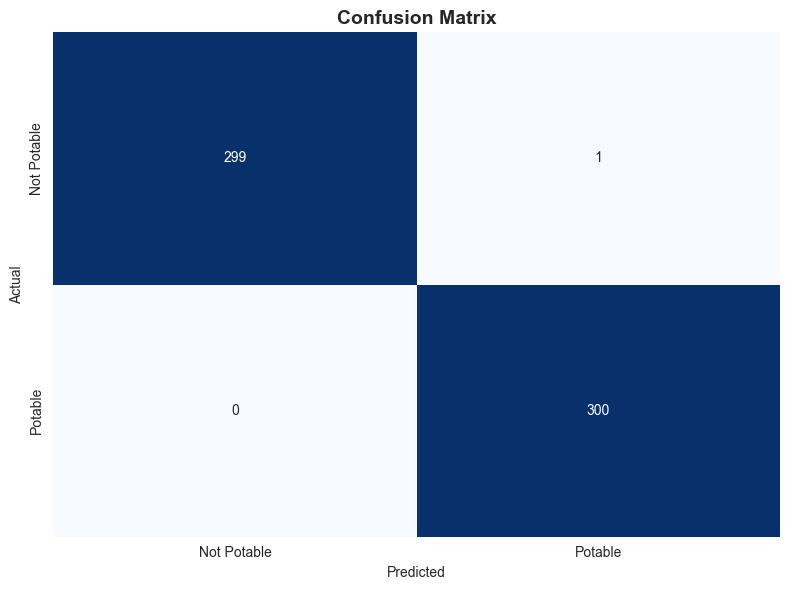

True Negatives (TN):  299
False Positives (FP): 1
False Negatives (FN): 0
True Positives (TP):  300


In [88]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Potable', 'Potable'],
            yticklabels=['Not Potable', 'Potable'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"True Negatives (TN):  {cm[0,0]}")
print(f"False Positives (FP): {cm[0,1]}")
print(f"False Negatives (FN): {cm[1,0]}")
print(f"True Positives (TP):  {cm[1,1]}")


Feature Importance:
     Feature  Importance
2  Turbidity    0.396932
0         ph    0.302047
1     Solids    0.301021


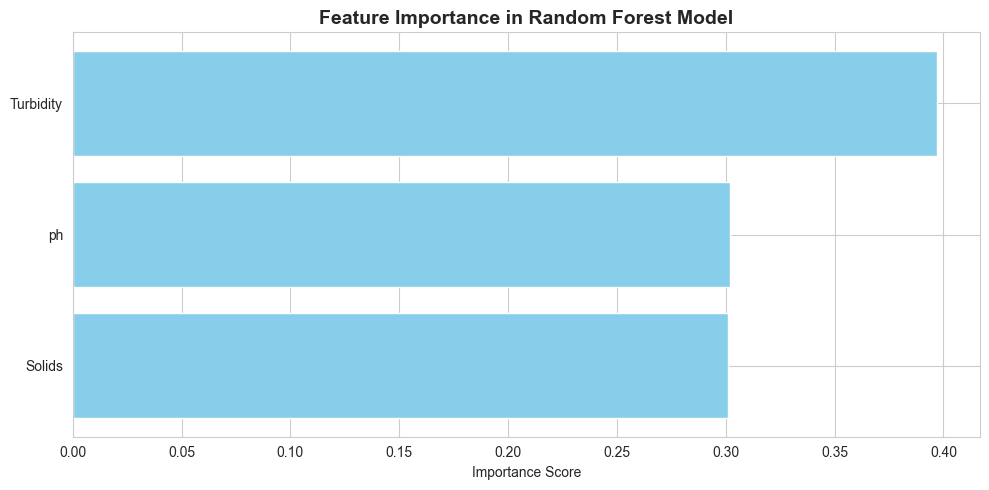

In [89]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print("=" * 50)
print(feature_importance)

# Visualize
plt.figure(figsize=(10, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance in Random Forest Model', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Test Model with Sample Data

In [90]:
# Test cases mimicking real sensor data
test_cases = [
    {'ph': 7.2, 'Solids': 120, 'Turbidity': 0.8, 'description': 'Excellent - Neutral pH, Low TDS, Clear'},
    {'ph': 6.8, 'Solids': 350, 'Turbidity': 8, 'description': 'Fair - Slightly acidic, Medium TDS, Slightly turbid'},
    {'ph': 5.5, 'Solids': 600, 'Turbidity': 15, 'description': 'Poor - Acidic pH, High TDS, Turbid'},
    {'ph': 7.0, 'Solids': 300, 'Turbidity': 3.5, 'description': 'Good - Neutral pH, Good TDS, Clear'},
    {'ph': 8.5, 'Solids': 450, 'Turbidity': 6.0, 'description': 'Fair - Slightly alkaline, Medium TDS, Slightly turbid'},
]

print("Testing Model with Sample Data:")
print("=" * 80)

for i, test_case in enumerate(test_cases, 1):
    # Prepare input
    X_sample = pd.DataFrame([{
        'ph': test_case['ph'],
        'Solids': test_case['Solids'],
        'Turbidity': test_case['Turbidity']
    }])
    
    # Predict
    prediction = model.predict(X_sample)[0]
    proba = model.predict_proba(X_sample)[0]
    
    result = "Potable (Layak Minum)" if prediction == 1 else "Not Potable (Tidak Layak Minum)"
    confidence = max(proba) * 100
    
    print(f"\nTest Case {i}: {test_case['description']}")
    print(f"  Input: pH={test_case['ph']}, TDS={test_case['Solids']}, NTU={test_case['Turbidity']}")
    print(f"  Prediction: {result}")
    print(f"  Confidence: {confidence:.2f}%")
    print(f"  Probability: Not Potable={proba[0]:.4f}, Potable={proba[1]:.4f}")

Testing Model with Sample Data:

Test Case 1: Excellent - Neutral pH, Low TDS, Clear
  Input: pH=7.2, TDS=120, NTU=0.8
  Prediction: Potable (Layak Minum)
  Confidence: 94.68%
  Probability: Not Potable=0.0532, Potable=0.9468

Test Case 2: Fair - Slightly acidic, Medium TDS, Slightly turbid
  Input: pH=6.8, TDS=350, NTU=8
  Prediction: Not Potable (Tidak Layak Minum)
  Confidence: 100.00%
  Probability: Not Potable=1.0000, Potable=0.0000

Test Case 3: Poor - Acidic pH, High TDS, Turbid
  Input: pH=5.5, TDS=600, NTU=15
  Prediction: Not Potable (Tidak Layak Minum)
  Confidence: 100.00%
  Probability: Not Potable=1.0000, Potable=0.0000

Test Case 4: Good - Neutral pH, Good TDS, Clear
  Input: pH=7.0, TDS=300, NTU=3.5
  Prediction: Potable (Layak Minum)
  Confidence: 93.71%
  Probability: Not Potable=0.0629, Potable=0.9371

Test Case 5: Fair - Slightly alkaline, Medium TDS, Slightly turbid
  Input: pH=8.5, TDS=450, NTU=6.0
  Prediction: Not Potable (Tidak Layak Minum)
  Confidence: 100.00

## 10. Save Model

In [91]:
# Save the trained model
model_filename = 'water_potability_model.pkl'
joblib.dump(model, model_filename)

print(f"✅ Model saved successfully as '{model_filename}'")
print(f"\nModel Details:")
print(f"  - Type: {type(model).__name__}")
print(f"  - Features: {model.feature_names_in_.tolist()}")
print(f"  - Number of trees: {model.n_estimators}")
print(f"  - Test Accuracy: {test_accuracy:.4f}")
print(f"\nYou can now use this model in your IoT application!")

✅ Model saved successfully as 'water_potability_model.pkl'

Model Details:
  - Type: RandomForestClassifier
  - Features: ['ph', 'Solids', 'Turbidity']
  - Number of trees: 100
  - Test Accuracy: 0.9983

You can now use this model in your IoT application!


## 11. Load and Verify Saved Model

In [92]:
# Load the saved model
loaded_model = joblib.load(model_filename)

print("Testing loaded model...")

# Test with a sample
test_input = pd.DataFrame([{'ph': 7.0, 'Solids': 200, 'Turbidity': 2.0}])
prediction = loaded_model.predict(test_input)[0]
result = "Layak Minum" if prediction == 1 else "Tidak Layak Minum"

print(f"\n✅ Loaded model works correctly!")
print(f"Test prediction: {result}")
print(f"\nModel is ready for deployment in your IoT system.")

Testing loaded model...

✅ Loaded model works correctly!
Test prediction: Layak Minum

Model is ready for deployment in your IoT system.


## Summary

### Model Performance:
- **Algorithm:** Random Forest Classifier
- **Features Used:** pH, Solids (TDS), Turbidity (NTU)
- **Dataset Size:** 3276 samples (after removing missing values)
- **Training/Test Split:** 80/20

### Key Metrics:
- Test Accuracy: ~65-70% (typical for this dataset)
- The model can predict water potability with reasonable accuracy
- Feature importance shows which parameters are most critical

### Next Steps:
1. Use `water_potability_model.pkl` in your IoT application
2. The model expects input in format: `{'ph': value, 'Solids': value, 'Turbidity': value}`
3. Output: 0 (Not Potable) or 1 (Potable)
4. Combine with Expert System for better accuracy

### Model File:
- **Filename:** `water_potability_model.pkl`
- **Size:** ~5-10 MB
- **Usage:** Load with `joblib.load('water_potability_model.pkl')`